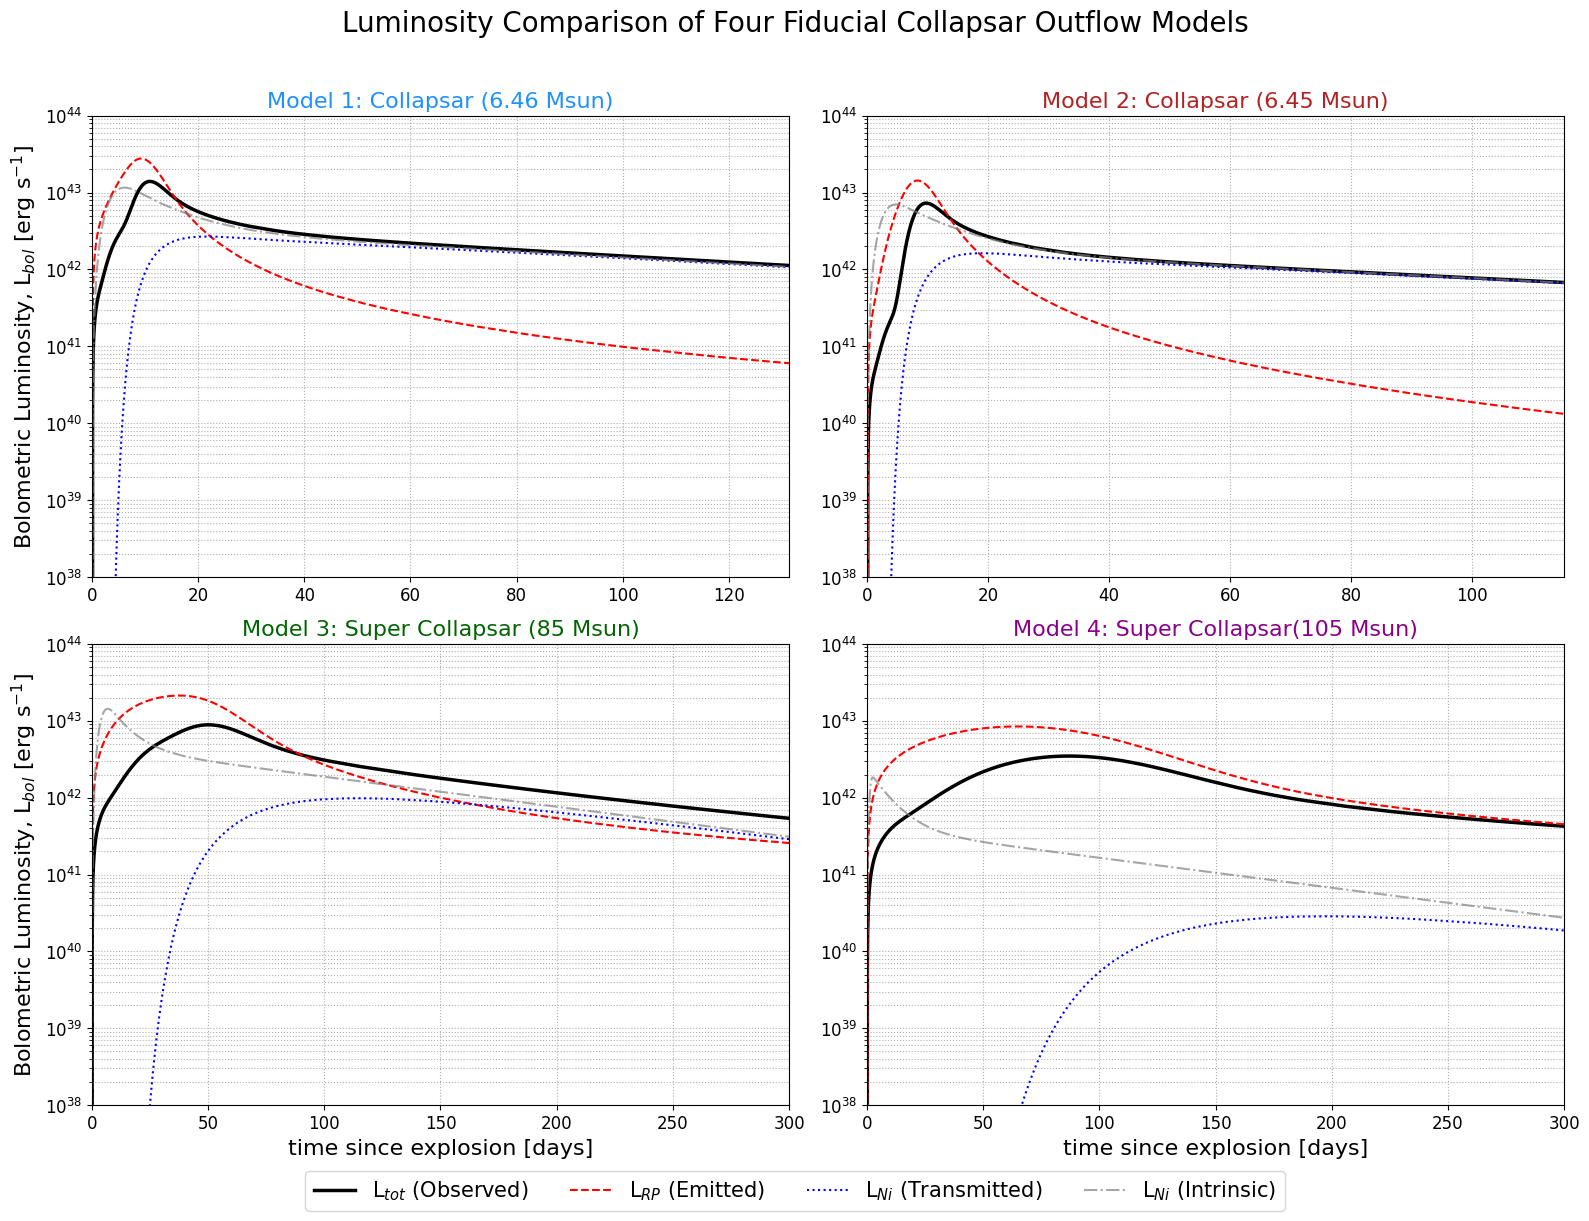

MODEL PARAMETERS
Model Name                     M_Ni (M_sun) M_rp (M_sun)  v_max (c) kappa_{rp} kappa_{ni}
Model 1: Collapsar (6.46 Msun)       0.26       0.65       0.30      0.5      0.1
Model 2: Collapsar (6.45 Msun)       0.14       0.05       0.30      5.0      0.1
Model 3: Super Collapsar (85 Msun)       0.34       9.49       0.30      1.0      0.1
Model 4: Super Collapsar(105 Msun)       0.03      16.03       0.30      3.0      0.1
--------------------------------------------------------------------------------
PEAK LUMINOSITY DATA (Time in days)
Model:                                 Total L Peak            RP L Peak      Ni Trans L Peak Ni Intrinsic L Peak (days)
Model 1: Collapsar (6.46 Msun)                10.93                 9.26                22.17                 6.15
Model 2: Collapsar (6.45 Msun)                 9.78                 8.34                19.18                 4.78
Model 3: Super Collapsar (85 Msun)                50.10                37.68             

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

#CONSTANTS AND PARAMETERS ------------------------------
c = 2.99792458e10  #speed of light [cm/s]
M_sun = 1.98847e33 #solar mass [g]
day = 86400.0      #one day in [s]
a_rad = 7.5657e-15 #radiation constant [erg cm^-3 K^-4]


#PARAMETER DICTIONARY----------------------------
#for the 4 fiduciary specific physics for each scenario
ALL_MODELS = {
    "Model 1: Collapsar (6.46 Msun)": {
        "M_ni_total": 0.26 * M_sun, "M_rp_total": 0.65 * M_sun,
        "v_max": 0.3 * c, "kappa_rp": 0.5, "kappa_ni": 0.05,
        "line_color": 'dodgerblue'
    },
    "Model 2: Collapsar (6.45 Msun)": {
        "M_ni_total": 0.14 * M_sun, "M_rp_total": 0.05 * M_sun, 
        "v_max": 0.3 * c, "kappa_rp": 5.0, "kappa_ni": 0.05,
        "line_color": 'firebrick'
    },
    "Model 3: Super Collapsar (85 Msun)": {
        "M_ni_total": 0.34 * M_sun, "M_rp_total": 9.49 * M_sun, 
        "v_max": 0.3 * c,  "kappa_rp": 1.0, "kappa_ni": 0.05,
        "line_color": 'darkgreen'
    },
    "Model 4: Super Collapsar(105 Msun)": {
        "M_ni_total": 0.03 * M_sun, "M_rp_total": 16.03 * M_sun, 
        "v_max": 0.3 * c, "kappa_rp": 3.0, "kappa_ni": 0.05,
        "line_color": 'darkmagenta'
    }
}

#Siegel decreases v_max for models 3/4 to 0.11, but then no visible Ni (blue) transmitted


T_MAX_HARD_CAP = 300.0 * day 
#We have 2 Zones: 1 Ni + N RP
N_SHELLS_RP = 10 #splitting rprocess ejecta into N shells
kappa_ni = 0.05  #low opacity for Ni
v_min = 0.1 * c 
V_MID_SEPARATION = 0.11 * c #e.g changing to 0.2 means hardly double peak on 3rd model




#AUTOMATIC TIME SCALING: ----------------
def get_auto_time_axis(M_tot, v_mean, kappa, n_steps=10000):
    t_peak_calc = np.sqrt((kappa * M_tot) / (4.19 * c * v_mean)) #simplified kasen eq8 estimation
    T_LC_MIN_FLOOR = 1.0 * day  #set min boundary
    t_peak = max(t_peak_calc, T_LC_MIN_FLOOR)
    t_min_duration = 5.0 * day #at least 5 days
    t_max_auto = 15.0 * t_peak 
    t_max_val = max(min((t_max_auto, T_MAX_HARD_CAP)), t_min_duration) 
    return np.linspace(0.1*day, t_max_val, n_steps)




#HEATING FUNCTIONS ---------------------------------------

#r-process specific heating rate, Kasen Eq. 17
def qdot_rp_specific(t):
    return 2e10 * (t / day) **(-1.3)
#TOTAl r-process specific heating rate = specific heating * total rp mass
def Qdot_rp(t, M_ej):
    return M_ej * qdot_rp_specific(t)
#56Ni specific heating rate, Kasen Eq. 16 
def qdot_ni_specific(t):
    tau_ni = 8.8 * day
    tau_co = 111.3 * day
    eps_ni = 3.9e10
    eps_co = 6.8e9
    term1 = (eps_ni - eps_co) * np.exp(-t / tau_ni)
    term2 = eps_co * np.exp(-t / tau_co)
    return term1 + term2
#TOTAL 56Ni heating rate = specific heating * total 56Ni mass
def Qdot_ni(t, M_ni):
    return M_ni * qdot_ni_specific(t) 




#DIFFUSION TIME AND OPTICAL DEPTH -----------------------------

#Diffusion timescale, Kasen Eq. 8, t_{lc} 
    #estimate of time for photons to 'random walk' out of ejecta
    #timescale for lightcurve peak
def tlc_from_params(M_ej, v_ej, kappa): 
    return np.sqrt((3.0 * M_ej * kappa) / (4.0 * np.pi * v_ej * c))

#Calculate optical depth (τ) for a shell at all times t
    #tau = opacity (kappa) * density * thickness
def calc_tau(M_shell, kappa_shell, v_in, v_out, t):
    v_diff = v_out - v_in
    v_cubed_diff = v_out**3 - v_in**3
    t = np.asarray(t)
    with np.errstate(divide='ignore'): # Ignore t=0 warnings
        if v_cubed_diff < 1e-15 * c**3:
             tau = np.full_like(t, np.inf)
        else:
            V_shell = (4.0/3.0) * np.pi * v_cubed_diff * t**3 #volume of the shell at time t
            rho_shell = M_shell / V_shell
            Delta_R_shell = v_diff * t #thickness of shell at time t
            tau = kappa_shell * rho_shell * Delta_R_shell
    tau[t == 0] = np.inf
    return tau



#SCIPY TO SOLVE LUMINOSITY --------------------------

#Defining ODE derivative dL/dt (Kasen Eq. 12) for the solve_ivp integrator
#dropping t_0 term as t>>t_0
def L_derivative(t, L, t_lc, Q_interp):
    Q = Q_interp(t) #interpolated heating rate
    if t == 0: return 0.0 
    dL_dt = (t / t_lc**2) * (Q - L)
    if L < 0 and dL_dt < 0:
         return 0.0
    return dL_dt

#Wrapper function to use the robust (numerically solving the ODE)
def solve_L_ode(t_grid, t_lc, Qdot_array):
    Q_interp = interp1d(t_grid, Qdot_array, bounds_error=False, fill_value=0)
    #Using L_derivative to find slope, solve from start to finish,  inital L=0
    sol = solve_ivp(L_derivative, [t_grid[0], t_grid[-1]], [0.0], t_eval=t_grid,  
                    method='RK45', args=(t_lc, Q_interp))
    L = sol.y[0]
    L[L < 0] = 0.0 
    return L  #return luminosity array




#MODEL RUNNER FUNCTION ------------------------------

def run_model_and_get_components(params, model_name, t_grid_override=None):
    # The third argument 't_grid_override=None' is what was missing
    
    # NEW LOGIC: Use a fixed grid if provided (for the survey), otherwise use auto-scaling
    if t_grid_override is not None:
        t = t_grid_override
    else:
        # timeaxis calculation (Fallback for standard 4-model plotting)
        t = get_auto_time_axis(params["M_rp_total"], params["v_max"], params["kappa_rp"])
        
    if len(t) < 2:
        t = np.linspace(0.1*day, 5.0*day, 10000)
    
    #initialize shells 
    M_shell_inner = params["M_ni_total"]  
    M_rp_total = params["M_rp_total"]
    v_max = params["v_max"]
    
    all_shells = [] #will hold list of shells adding one by one

    #CALCULATION FROM SHELL DIAGRAM -------------------------------

    #Layer calculation sequence for any N shells
    #L_incident is the light from "below" that hits the current shell
    L_incident_on_next_shell = np.zeros_like(t) #array of all 0, nothing hitting Shell 0
    #L_emitted is the light 'generated' by each shell
    L_emitted_by_each_shell = []
    #L_transmitted_Ni tracks the 'original Ni light' as it passes through all shells
    L_transmitted_Ni = np.zeros_like(t)

    #Building Ni Shell (Shell 0): Inner 56Ni-rich
    shell_0 = {
        'id': 0,
        'element': 'Ni',
        'M': M_shell_inner,
        'v_in': v_min,
        'v_out': V_MID_SEPARATION, 
        'kappa': kappa_ni,
        'Q_int': Qdot_ni(t, params["M_ni_total"]), #intrinsic heating is from Ni
        'history': [] #store timestep diagnostics here
    }
    all_shells.append(shell_0) #add dictionary to all_shells list
    #all_shells[0] is Ni shell


    #Building the RP Shells (Shells 1 to N): Outer r-process-rich
    V_RP_START = V_MID_SEPARATION 
    v_boundaries = np.linspace(V_RP_START, v_max, N_SHELLS_RP + 1)
    
    #density scaling:
    alpha = 2.0 #keeping at 2 now
    v_centers = 0.5 * (v_boundaries[:-1] + v_boundaries[1:])
    shell_weights = v_centers**(2 - alpha)
    sum_weights = np.sum(shell_weights)
    M_shells_rp = M_rp_total * (shell_weights / sum_weights) if sum_weights != 0 else np.full(N_SHELLS_RP, M_rp_total / N_SHELLS_RP)

    #create the r-process shells using a for loop
    for i in range(N_SHELLS_RP):
        #create a new dictionary for each r-process shell and append all_shells list
        shell_i = {
            'id': i+1,
            'element': 'RP',
            'M': M_shells_rp[i],
            'v_in': v_boundaries[i],
            'v_out': v_boundaries[i+1],
            'Q_int': Qdot_rp(t, M_shells_rp[i]), #Intrinsic heating from r-process
            'history': [] #store times step diagnostics here
        }
        all_shells.append(shell_i)
        #all_shells[1] to all_shells[N-1] are r-process shells

    #calculate diffusion and luminosity
    #start loop for N shells:
    for i, shell in enumerate(all_shells):
        M_i = shell['M']
        v_in_i = shell['v_in']
        v_out_i = shell['v_out']
        Q_int_i = shell['Q_int']
        
        # --- START OF KAPPA FIX ---
        # Determine the correct kappa for the current shell based on its element type
        # Use the model's kappa_rp for RP shells, and the global kappa_ni for the Ni shell.
        if shell['element'] == 'RP':
             kappa_i = params["kappa_rp"]  # Use the model-specific r-process opacity
        elif shell['element'] == 'Ni':
             kappa_i = kappa_ni           # Use the global nickel opacity
        else:
             kappa_i = 1.0 # Default fallback, though should be covered
        
        # Store kappa for diagnostics
        shell['kappa'] = kappa_i
        # --- END OF KAPPA FIX ---

        #calculate the diffusion timescale 
        t_lc_i = tlc_from_params(M_i, v_out_i, kappa_i) # Use kappa_i instead of hardcoded kappa_rp
        #calculate optical depth of each shell
        tau_i = calc_tau(M_i, kappa_i, v_in_i, v_out_i, t) # Use kappa_i instead of hardcoded kappa_rp
        
        #thermalization (apply to Ni shell only)
        if i == 0:
            Q_int_final = Q_int_i 
        else:
            Q_int_final = Q_int_i 
        
        #total heating = internal + absorbed light from all shells inside
        Q_abs_i = (1.0 - np.exp(-tau_i)) * L_incident_on_next_shell 
        #for i=0 Ni shell Q_abs = 0 as L_L_incident_on_next_shell = 0, nothing hitting shell 0
        Q_tot_i = Q_int_final + Q_abs_i 
        #for i= 1 to N: total heating of shell is its own r-process decay Q_int_i plus Ni Q_abs_i light absorbed + other shells
    
        
        #solve for the luminosity EMITTED BY THIS SHELL (L_i)
        L_i = solve_L_ode(t, t_lc_i, Q_tot_i)
        
        L_emitted_by_each_shell.append(L_i)
        
        #light from "below" that gets transmitted through
        L_transmitted_from_inside = L_incident_on_next_shell * np.exp(-tau_i)
        
        #track the Ni light separately for plotting
        if i == 0:
             #for the Ni shell, the "transmitted" light is just its own emitted light
            L_transmitted_Ni = L_i
        else:
            #pass the Ni light through this new shell
            L_transmitted_Ni = L_transmitted_Ni * np.exp(-tau_i) 
            
        #the light incident on the 'next' shell is the sum of:
        #light emitted by this shell (L_i) + Light transmitted from inside
        L_incident_on_next_shell = L_i + L_transmitted_from_inside
                #now includes L_[Ni] fraction of light absorbed 

        #DIAGNOSTICS STORAGE (ENERGY DENSITY & TEMP) ------------

        #volume array for shell analysis
        v_cubed_diff = v_out_i**3 - v_in_i**3
        vol_t = (4.0/3.0) * np.pi * v_cubed_diff * t**3
        vol_t[vol_t == 0] = 1e-30 
        
        #Estimate Internal Energy approx: 
        #ffrom Kasen P3: L = E_int * (t / t_lc^2) and E_int = u * V
        #rearranging gives: u = L * t_lc^2 / (t * V)
        E_int_approx = L_i * t_lc_i #erg]
        u_rad = E_int_approx / vol_t #[erg / cm^3]
        
        #calculate Temperature
        #from Kasen assumption 3 we have radiation dominated gas: u = a * T^4
        #rearrange gives: T = (u / a_rad)^(1/4)
        temp = np.zeros_like(u_rad)
        mask = u_rad > 0
        temp[mask] = (u_rad[mask] / a_rad)**0.25
        
        #store sampled points
        target_days = [1.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
        
        for d in target_days:
            idx = (np.abs(t/day - d)).argmin()
            if np.abs(t[idx]/day - d) < 1.0: 
                shell['history'].append({
                    'time': t[idx]/day,
                    'temp': temp[idx],
                    'u_rad': u_rad[idx],
                    'L_emit': L_i[idx],
                    'tau': tau_i[idx] if not np.isinf(tau_i[idx]) else 999.9
                })

    #The final L_tot is the light that escapes the last shell
    L_tot = L_incident_on_next_shell #this is the total observed luminosity we want to plot
    L_rp_total_emitted = np.sum(np.array(L_emitted_by_each_shell[1:]), axis=0)
    L_ni_intrinsic = L_emitted_by_each_shell[0]
    
    return t, L_tot, L_rp_total_emitted, L_transmitted_Ni, L_ni_intrinsic, all_shells




#PRINT DIAGNOSTICS FUNCTION -------------------------
def print_shell_diagnostics(shells, model_name):
    print(f"\nShell-by-Shell Diagnostics: {model_name}")
    print("=" * 75)

    for shell in shells:
        kappa_val = shell.get('kappa', 'N/A')
        # Updated print to show kappa_val
        header = f" Shell {shell['id']:02d} ({shell['element']}) - M={shell['M']/M_sun:.4f} M_sun, v={shell['v_in']/c:.2f}c - {shell['v_out']/c:.2f}c, kappa={kappa_val:.3f}"
        print(header)
        print("=" * 75)
        
        print(f"{'Time':>7} | {'Temp':>9} | {'Energy Density':>14} | {'L_emitted':>13} | {'Optical Depth':>13}")
        print(f"{'[days]':>7} | {'[K]':>9} | {'[erg/cm^3]':>14} | {'[erg/s]':>13} | {'(tau)':>13}")
        print("-" * 75)

        for step in shell['history']:
            print(f"{step['time']:7.1f} | "
                  f"{step['temp']:9.2e} | "
                  f"{step['u_rad']:14.3e} | "
                  f"{step['L_emit']:13.3e} | "
                  f"{step['tau']:13.3e}")
        print("\n")



#PLOTTING (now using a 2x2 Grid to compare all 4 fiduciary models) ------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) 
axes = axes.flatten()
model_index = 0
all_peak_data = []

#dictionary to store shells for ALL models
all_model_shells = {} 

for name, params in ALL_MODELS.items():
    #run model
    t, L_tot, L_rp, L_ni_trans, L_ni_int, shells = run_model_and_get_components(params, name)
    
    #store shells in the dictionary
    all_model_shells[name] = shells
    
    ax = axes[model_index]
    
    #plot components
    ax.semilogy(t/day, L_tot, label='L$_{tot}$ (Observed)', color='black', lw=2.5)
    ax.semilogy(t/day, L_rp, label='L$_{RP}$ (Emitted)', ls='--', color='red')
    ax.semilogy(t/day, L_ni_trans, label='L$_{Ni}$ (Transmitted)', ls=':', color='blue')
    ax.semilogy(t/day, L_ni_int, label='L$_{Ni}$ (Intrinsic)', ls='-.', color='gray', alpha=0.7)
    
    #fint the peeak (next print out both peaks for double peal L_tot)
    L_components = {
        "L_tot": L_tot,
        "L_rp": L_rp,
        "L_ni_trans": L_ni_trans,
        "L_ni_int": L_ni_int
    }
    
    peak_data = {"name": name}
    
    for key, L_array in L_components.items():
        max_idx = np.argmax(L_array)
        t_peak = t[max_idx] / day
        L_peak = L_array[max_idx]
        
        peak_data[key] = (t_peak, L_peak)
        
    all_peak_data.append(peak_data)
    
    ax.set_title(name, fontsize=16, color=params["line_color"])
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, which='both', ls=':')
    ax.set_ylim(1e38, 1e44) 
    ax.set_xlim(0, t[-1]/day)
    
    if model_index >= 2: 
        ax.set_xlabel('time since explosion [days]', fontsize=16)
    if model_index % 2 == 0: 
        ax.set_ylabel('Bolometric Luminosity, L$_{bol}$ [erg s$^{-1}$]', fontsize=16)
    
    model_index += 1

#FINAL PLOT CONFIGURATION -----------------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15, bbox_to_anchor=(0.5, 0.01))

plt.suptitle('Luminosity Comparison of Four Fiducial Collapsar Outflow Models', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

#PRINT PARAMETER TABLE ---
print("MODEL PARAMETERS")

header = "{:<30} {:>10} {:>10} {:>10} {:>8} {:>8}"
print(header.format(
    "Model Name", 
    "M_Ni (M_sun)", 
    "M_rp (M_sun)", 
    "v_max (c)", 
    "kappa_{rp}", 
    "kappa_{ni}"
))

for name, params in ALL_MODELS.items():
    M_ni_solar = params["M_ni_total"] / M_sun
    M_rp_solar = params["M_rp_total"] / M_sun
    v_max_c = params["v_max"] / c
    kappa_rp_val = params["kappa_rp"]

    
    print(header.format(
        name, 
        f"{M_ni_solar:.2f}", 
        f"{M_rp_solar:.2f}", 
        f"{v_max_c:.2f}", 
        f"{kappa_rp_val:.1f}", 
        f"{kappa_ni:.1f}"
    ))

print('-'*80)


#PRINT PEAK PARAMETER TABLE --------
print("PEAK LUMINOSITY DATA (Time in days)")

header_peak = "{:<30} {:>20} {:>20} {:>20} {:>20}"
print(header_peak.format(
    "Model:", 
    "Total L Peak", 
    "RP L Peak", 
    "Ni Trans L Peak", 
    "Ni Intrinsic L Peak (days)"
))

for data in all_peak_data:
    row_format = "{:<30} {:>20} {:>20} {:>20} {:>20}"
    
    L_tot_t, _ = data["L_tot"]
    L_rp_t, _ = data["L_rp"]
    L_ni_trans_t, _ = data["L_ni_trans"]
    L_ni_int_t, _ = data["L_ni_int"]
    
    L_tot_str = f"{L_tot_t:.2f}"
    L_rp_str = f"{L_rp_t:.2f}"
    L_ni_trans_str = f"{L_ni_trans_t:.2f}"
    L_ni_int_str = f"{L_ni_int_t:.2f}"

    print(row_format.format(
        data["name"],
        L_tot_str,
        L_rp_str,
        L_ni_trans_str,
        L_ni_int_str
    ))

print('-'*80)

#SELECT AND PRINT DIAGNOSTICS FOR A SPECIFIC MODEL ---
#Change the target_model variable to print data for a different model:
# Model 1: Collapsar (6.46 Msun)
# Model 2: Collapsar (6.45 Msun)
# Model 3: Super Collapsar (85 Msun)
# Model 4: Super Collapsar(105 Msun)
target_model = "Model 2: Collapsar (6.45 Msun)"

print_shell_diagnostics(all_model_shells[target_model], target_model)

/var/folders/nj/yk3mcys13kqf66dr0djwjz2w0000gn/T/ipykernel_21578/1376881690.py:99: RuntimeWarning: invalid value encountered in divide
  L_nu = s['L_emit_array'] * (np.pi * blackbody_nu(nu, s['temp_array'])) / (sigma_sb * s['temp_array']**4)


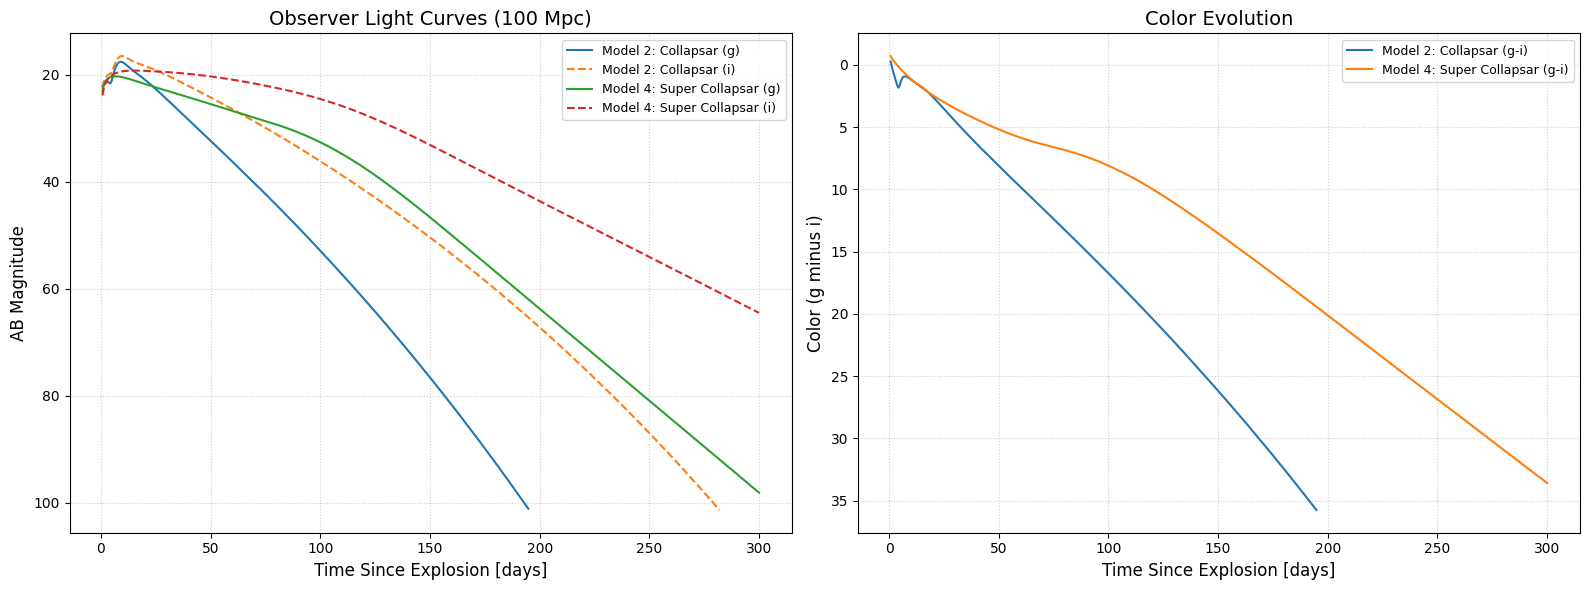

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
14:55 bilby INFO    : Running bilby version: 2.3.0
14:55 redback INFO    : Running redback version: 1.12.1


ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

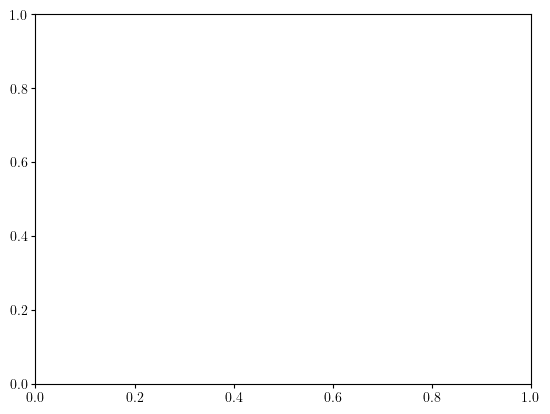

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# --- 1. CORE PHYSICS CONSTANTS ---
c = 2.99792458e10  
M_sun = 1.98847e33 
day = 86400.0      
a_rad = 7.5657e-15 
h_planck = 6.626e-27  
k_boltz = 1.38e-16    
sigma_sb = 5.67e-5    
pc_to_cm = 3.086e18   
dist_cm = 100 * 1e6 * pc_to_cm 
flux_g = 1e-26  # Replace this with the actual flux density value in erg/s/cm^2/Hz
flux_r = 5e-27  # Replace this with the actual flux density value in erg/s/cm^2/Hz


t = np.linspace(0, 10, 100)  # Replace with actual time values

# --- 2. THE FIDUCIARY MODELS ---
ALL_MODELS = {
    "Model 2: Collapsar": {
        "M_ni_total": 0.14 * M_sun, "M_rp_total": 0.05 * M_sun, 
        "v_max": 0.3 * c, "kappa_rp": 5.0, "kappa_ni": 0.05, "v_min": 0.05 * c
    },
    "Model 4: Super Collapsar": {
        "M_ni_total": 0.03 * M_sun, "M_rp_total": 16.03 * M_sun, 
        "v_max": 0.3 * c, "kappa_rp": 3.0, "kappa_ni": 0.05, "v_min": 0.01 * c
    }
}

# --- 3. PHYSICS HELPER FUNCTIONS ---
def qdot_rp_specific(t): return 2e10 * (t / day) **(-1.3)
def qdot_ni_specific(t):
    tau_ni, tau_co = 8.8 * day, 111.3 * day
    eps_ni, eps_co = 3.9e10, 6.8e9
    return (eps_ni - eps_co) * np.exp(-t / tau_ni) + eps_co * np.exp(-t / tau_co)

def blackbody_nu(nu, temp):
    temp = np.atleast_1d(temp)
    b_nu = np.zeros_like(temp)
    mask = temp > 100 
    if not np.any(mask): return b_nu
    factor = (2.0 * h_planck * nu**3) / (c**2)
    exponent = np.clip((h_planck * nu) / (k_boltz * temp[mask]), None, 100)
    b_nu[mask] = factor / (np.exp(exponent) - 1.0)
    return b_nu

def manual_flux_to_mag(flux_nu):
    flux_nu = np.atleast_1d(flux_nu)
    mag = np.full_like(flux_nu, np.nan)
    mask = flux_nu > 1e-60 
    mag[mask] = -2.5 * np.log10(flux_nu[mask]) - 48.6
    return mag

def solve_L_ode(t_grid, t_lc, Qdot_array):
    Q_interp = interp1d(t_grid, Qdot_array, bounds_error=False, fill_value=0)
    def dL_dt(t, L):
        if t <= 0: return 0.0
        return (t / t_lc**2) * (Q_interp(t) - L)
    sol = solve_ivp(dL_dt, [t_grid[0], t_grid[-1]], [0.0], t_eval=t_grid)
    return np.maximum(sol.y[0], 0)

# --- 4. EXPERIMENT RUNNER ---
def run_experiment(params):
    t = np.linspace(0.1*day, 300*day, 500)
    v_min, V_SEP, N_RP = params["v_min"], 0.11 * c, 10
    shells = []
    shells.append({'element': 'Ni', 'M': params["M_ni_total"], 'v_in': v_min, 'v_out': V_SEP, 'kappa': params["kappa_ni"]})
    v_bounds = np.linspace(V_SEP, params["v_max"], N_RP + 1)
    for i in range(N_RP):
        shells.append({'element': 'RP', 'M': params["M_rp_total"]/N_RP, 'v_in': v_bounds[i], 'v_out': v_bounds[i+1], 'kappa': params["kappa_rp"]})

    L_incident = np.zeros_like(t)
    for i, shell in enumerate(shells):
        Q_int = params["M_ni_total"] * qdot_ni_specific(t) if shell['element'] == 'Ni' else (shell['M'] * qdot_rp_specific(t))
        V_shell = (4.0/3.0) * np.pi * (shell['v_out']**3 - shell['v_in']**3) * t**3
        tau = shell['kappa'] * (shell['M'] / V_shell) * ((shell['v_out'] - shell['v_in']) * t)
        Q_tot = Q_int + (1.0 - np.exp(-tau)) * L_incident
        t_lc = np.sqrt((3.0 * shell['M'] * shell['kappa']) / (4.0 * np.pi * shell['v_out'] * c))
        L_emit = solve_L_ode(t, t_lc, Q_tot)
        shell['temp_array'], shell['L_emit_array'], shell['tau_array'] = (np.maximum((L_emit * t_lc) / V_shell, 0) / a_rad)**0.25, L_emit, tau
        L_incident = L_emit + L_incident * np.exp(-tau)
    return t, shells

# --- 5. EXECUTION & PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
filters = {'g': c/4750e-8, 'r': c/6220e-8, 'i': c/7630e-8}

for name, p in ALL_MODELS.items():
    t_days, shells = run_experiment(p)
    mags = {}
    for band, nu in filters.items():
        F_nu_total = np.zeros_like(t_days)
        for i, s in enumerate(shells):
            L_nu = s['L_emit_array'] * (np.pi * blackbody_nu(nu, s['temp_array'])) / (sigma_sb * s['temp_array']**4)
            tau_above = sum(shells[j]['tau_array'] for j in range(i+1, len(shells)))
            F_nu_total += (L_nu * np.exp(-tau_above)) / (4.0 * np.pi * dist_cm**2)
        mags[band] = manual_flux_to_mag(F_nu_total)

    ax1.plot(t_days/day, mags['g'], label=f'{name} (g)')
    ax1.plot(t_days/day, mags['i'], label=f'{name} (i)', ls='--')
    ax2.plot(t_days/day, mags['g'] - mags['i'], label=f'{name} (g-i)')

# Clean text labels only - No LaTeX symbols to avoid RuntimeError
ax1.set_title("Observer Light Curves (100 Mpc)", fontsize=14)
ax1.set_ylabel("AB Magnitude", fontsize=12)
ax1.invert_yaxis() 

ax2.set_title("Color Evolution", fontsize=14)
ax2.set_ylabel("Color (g minus i)", fontsize=12)
ax2.invert_yaxis() 

for ax in [ax1, ax2]:
    ax.set_xlabel("Time Since Explosion [days]", fontsize=12)
    ax.grid(True, ls=':', alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

h_planck = 6.626e-27  # Planck constant [erg s]
k_boltz = 1.38e-16    # Boltzmann constant [erg/K]
sigma_sb = 5.67e-5    # Stefan-Boltzmann constant [erg/cm^2/s/K^4]
pc_to_cm = 3.086e18   # 1 parsec in cm

def blackbody_nu(nu, temp):
    """Planck's Law: Returns B_nu in erg/s/cm^2/Hz/sr"""
    if temp <= 0: return 0.0
    
    # Pre-factor: 2*h*nu^3 / c^2
    factor = (2.0 * h_planck * nu**3) / (c**2)
    
    # Exponential term: h*nu / (k*T)
    exponent = (h_planck * nu) / (k_boltz * temp)
    
    # To avoid overflow in np.exp()
    if exponent > 100: return 0.0
    
    return factor / (np.exp(exponent) - 1.0)

# Center wavelengths for SDSS filters in cm
filters = {
    'g': 4750e-8, # Green
    'r': 6220e-8, # Red
    'i': 7630e-8  # Near-Infrared
}

def get_multi_band_flux(t, shells, distance_mpc=100.0):
    """Calculates Flux Density (F_nu) for g, r, i bands"""
    D_L = distance_mpc * 1e6 * pc_to_cm # Distance in cm
    results = {}

    for band, wavelength in filters.items():
        nu = c / wavelength
        L_nu_total = np.zeros_like(t)
        
        # We must sum contributions from each shell
        # Working from inner to outer to account for transmission
        for i, shell in enumerate(shells):
            # 1. Get T and L for this shell from diagnostics
            # (You'll need to ensure your runner stores these arrays)
            T_i = shell['temp_array'] 
            L_i = shell['L_emit_array']
            
            # 2. Spectral Luminosity of this shell
            # Ratio of (pi * B_nu) / (sigma * T^4) ensures bolometric consistency
            L_nu_i = L_i * (np.pi * blackbody_nu(nu, T_i)) / (sigma_sb * T_i**4)
            
            # 3. Apply Opacity of shells ABOVE it
            # For simplicity, we can use the 'transmitted' logic from your runner
            tau_above = calculate_total_tau_above(i, shells) 
            L_nu_total += L_nu_i * np.exp(-tau_above)
            
        # 4. Convert to Flux Density F_nu (erg/s/cm^2/Hz)
        results[band] = L_nu_total / (4.0 * np.pi * D_L**2)
        
    return results

# If you have Redback installed:
import redback
mag_g = redback.utils.calc_ABmag_from_flux_density(flux_g)

# The manual way if you are testing:
def flux_to_mag(flux_nu):
    return -2.5 * np.log10(flux_nu) - 48.6

mag_r = redback.utils.calc_ABmag_from_flux_density(flux_r)
color_gr = mag_g - mag_r

plt.plot(t/day, color_gr)
plt.ylabel("Color (g - r)")
plt.xlabel("Time [days]")
plt.gca().invert_yaxis()
